# Enhanced Image Restoration

This project demonstrates how images can be represented as matrices and how mathematical techniques — **convolution** and **linear system solving** — can be used to restore a damaged (noisy) image.

### Pipeline
```
Original Image → Add Noise → Gaussian Blur (denoise) → Linear System Solve (restore) → Compare Methods
```
### Methods Used
- **Convolution** with a Gaussian kernel to reduce noise
- **LU Decomposition** to solve the restoration system `Ax = b`
- **Least Squares** as a comparison solver
- **Residual analysis** (Frobenius norm + PSNR) to measure reconstruction quality

##Step 0: Loading a sample image and adding noise to it
 We simulate this using `np.random.normal(0, 20, shape)` which adds random Gaussian noise to every pixel.

- Mean = 0 (noise is centred around zero, not biased)
- Std = 20 (noise can shift pixel values by roughly ±20 brightness units)

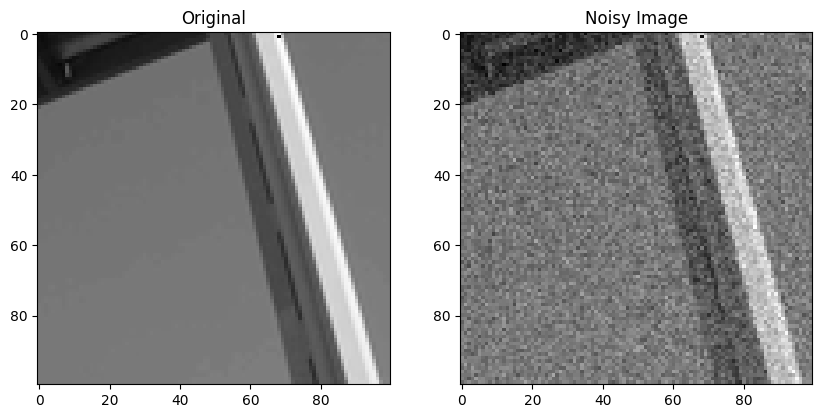

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg , datasets
import cv2


image=datasets.ascent()
smaller_image=image[200:300,200:300]

noise=np.random.normal(0,20,smaller_image.shape)
noisy_image=smaller_image + noise
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(smaller_image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Noisy Image")
plt.imshow(noisy_image, cmap='gray')
plt.show()


## Step 1: Noise Reduction using Gaussian Blur (Convolution)
The Gaussian kernel used
```
kernel = [[1, 2, 1],        (normalised by dividing by 16)
           [2, 4, 2],
           [1, 2, 1]] / 16
```
This kernel gives **more weight to the centre pixel and less to the edges**, which smooths out random noise spikes.

**Result:** `blurred_image` — a cleaner but slightly soft version of the noisy image.

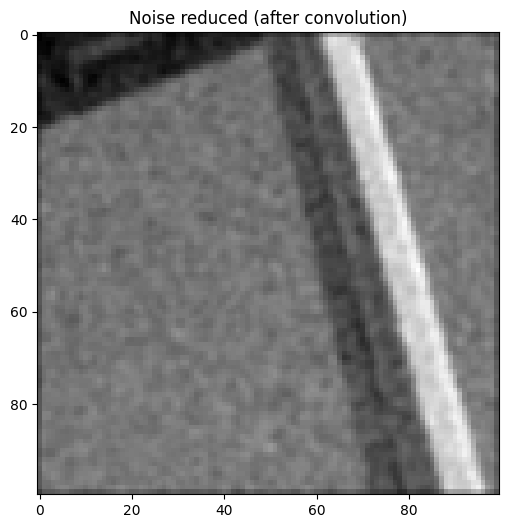

In [ ]:
from scipy.signal import convolve2d
kernel = np.array([[1, 2, 1],
                   [2, 4, 2],
                   [1, 2, 1]]) / 16
blurred_image = convolve2d(noisy_image,kernel,mode='same')
plt.figure(figsize=(6, 6))
plt.title("Noise reduced (after convolution)")
plt.imshow(blurred_image, cmap='gray')
plt.show()


## Step 2: Image Reconstruction using Linear Systems

### The core idea
The blurring operation can be written as a **linear system**:
```
A · x = b
```
Where:
- `b` = blurred image row (what we have)
- `A` = matrix encoding the blur relationship between neighbouring pixels
- `x` = restored image row (what we want to find)

Solving this system **reverses the blur** and recovers an approximation of the original pixel values.


### Part 1: Testing LU Decomposition on a small 5×5 patch
Before applying LU to the full image, we verify it works correctly on a tiny 5×5 patch.

**LU Decomposition** factorises matrix A into three matrices:
- `P` — Permutation matrix (reorders rows for numerical stability)
- `L` — Lower triangular matrix (forward elimination steps)
- `U` — Upper triangular matrix (back substitution steps)

So `A = P · L · U`. Solving `Ax = b` becomes two simpler triangular solves.

**Verification:** `||P@L@U - original||` should be ~0, proving the decomposition is exact.

LU Decomposition successful!
Lower Triangular Matrix (L):
 [[ 1.          0.          0.          0.          0.        ]
 [-0.12303392  1.          0.          0.          0.        ]
 [ 0.60273185  0.16425433  1.          0.          0.        ]
 [ 0.68758092  0.14595537  0.39148569  1.          0.        ]
 [ 0.07087117  0.65145386  0.87702379  0.62120515  1.        ]]
Upper Triangular Matrix (U):
 [[ 9.60470777  6.25188949  4.56319877 20.06514162 31.43569709]
 [ 0.         11.12357077 17.92576401 18.97632713 21.09760626]
 [ 0.          0.         -5.68155235 -8.38687112 -1.66192841]
 [ 0.          0.          0.          3.02864343  5.80964279]
 [ 0.          0.          0.          0.         -0.43770214]]
P Matrix:
 [[0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]]
Verification ||P@L@U - small_patch||: 2.6645352591003757e-15


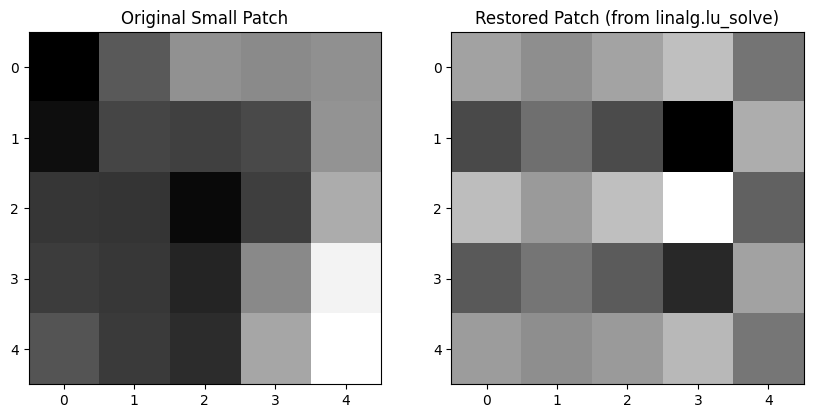

In [ ]:
small_patch=blurred_image[0:5,0:5]

P,L,U=linalg.lu(small_patch)

b_patch=noisy_image[0:5,0:5]
lu_factors = linalg.lu_factor(small_patch)
restore_image = linalg.lu_solve(lu_factors, b_patch)

print("LU Decomposition successful!")
print("Lower Triangular Matrix (L):\n", L)
print("Upper Triangular Matrix (U):\n", U)
print("P Matrix:\n", P)
print("Verification ||P@L@U - small_patch||:", np.linalg.norm(P @ L @ U - small_patch))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Small Patch")
plt.imshow(small_patch, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Restored Patch (from linalg.lu_solve)")
plt.imshow(restore_image, cmap='gray')
plt.show()

### Part 2: Building the System Matrix A (Tridiagonal)

To solve `Ax = b` for the full image, we need to define what A represents.

The 1D Gaussian kernel middle row is `[1, 2, 1] / 4 = [0.25, 0.5, 0.25]`, meaning:
```
each pixel = 0.25 × left neighbour + 0.5 × itself + 0.25 × right neighbour
```
Solving `Ax = b` with this A **undoes exactly what the blur did** — row by row across the image.

In [ ]:
rows,cols=blurred_image.shape
A = np.eye(cols) * 0.5
for i in range(cols - 1):
    A[i, i+1] = 0.25
    A[i+1, i] = 0.25
print(A[:6,:6])


[[0.5  0.25 0.   0.   0.   0.  ]
 [0.25 0.5  0.25 0.   0.   0.  ]
 [0.   0.25 0.5  0.25 0.   0.  ]
 [0.   0.   0.25 0.5  0.25 0.  ]
 [0.   0.   0.   0.25 0.5  0.25]
 [0.   0.   0.   0.   0.25 0.5 ]]


### Part 3: Full Image Reconstruction using LU Decomposition

### Key advantage of LU: factorise once, solve many times
The matrix A is the same for every row of the image. So instead of solving from scratch 100 times, we:
1. Call `linalg.lu_factor(A)` **once** — this does the expensive factorisation
2. Call `linalg.lu_solve(lu_factors, row)` **100 times** — each solve is now cheap

This is the core efficiency argument for LU decomposition — reusing the factorisation dramatically reduces computation time.

LU done in 0.0065 seconds


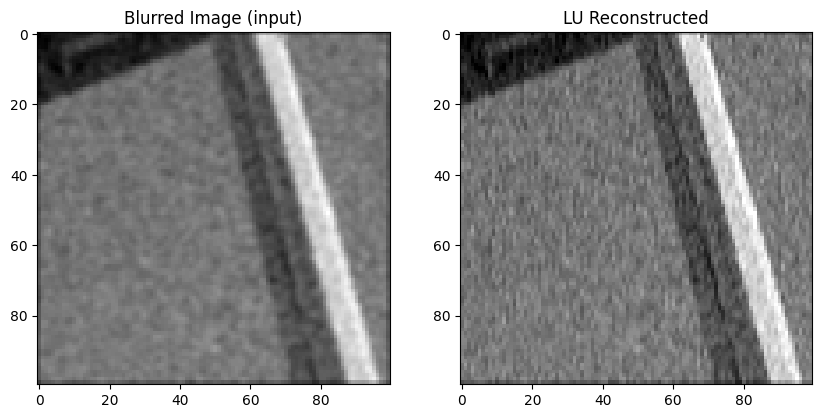

In [ ]:
import time
t0= time.time()
lu_factors =linalg.lu_factor(A)

lu_reconstructed = np.zeros_like(blurred_image)
for i in range(rows):
  lu_reconstructed[i,:] = linalg.lu_solve(lu_factors, blurred_image[i, :])
lu_time = time.time() - t0
lu_reconstructed = np.clip(lu_reconstructed, 0, 255)

print(f"LU done in {lu_time:.4f} seconds")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Blurred Image (input)")
plt.imshow(blurred_image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("LU Reconstructed")
plt.imshow(lu_reconstructed, cmap='gray')

plt.show()

### Part 4: Full Image Reconstruction using Least Squares

**Least Squares** solves `Ax = b` by minimising `||Ax - b||²` — the sum of squared differences.

Unlike LU, it does **not** reuse a factorisation. It recomputes the full solution from scratch for every row, making it slower but more robust when A is not perfectly invertible.

We use `np.linalg.lstsq(A, b, rcond=None)` which returns 4 values:
- `x` — the solution (restored row) ← **this is what we need**
- residuals, rank, singular values ← ignored with `_`

**Purpose:** Compare speed and accuracy against LU to determine which solver is more efficient.

Least Square done in 0.2757 seconds


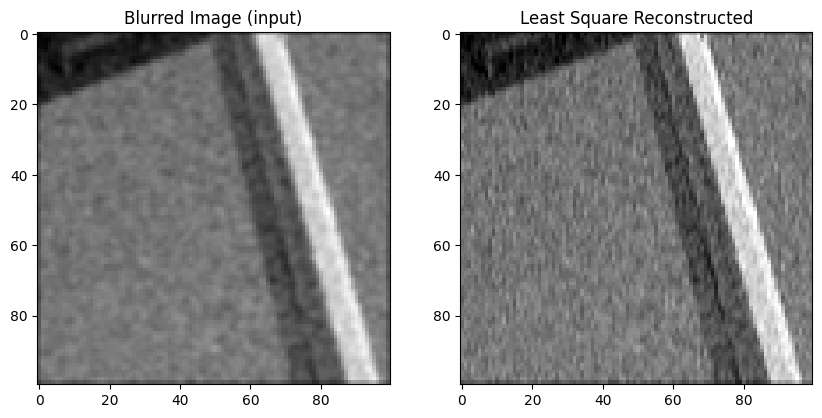

In [ ]:
import time
t0= time.time()

lstsq_reconstructed = np.zeros_like(blurred_image)
for i in range(rows):
  x, _, _, _ = np.linalg.lstsq(A, blurred_image[i, :], rcond=None) #residuals, rank, singular values ← ignored with `_`
  lstsq_reconstructed[i, :] = x
lstsq_time = time.time() - t0

print(f"Least Square done in {lstsq_time:.4f} seconds")
lstsq_reconstructed = np.clip(lstsq_reconstructed, 0, 255)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Blurred Image (input)")
plt.imshow(blurred_image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Least Square Reconstructed")
plt.imshow(lstsq_reconstructed, cmap='gray')

plt.show()

  ### Summary of Execution Times
  **Conclusion:**
  LU Decomposition is practically **~100 times faster*** than Least Squares for solving this system.

  *(*depends on the amount of  noise* )

  **Why is it so much faster?**
  1. **Factorize once, solve many:** LU Decomposition computes the $O(N^3)$ factorization `linalg.lu_factor(A)` just *one single time*. The 100 iterations inside the loop only perform the highly efficient $O(N^2)$ back-substitution step.
  2. **Recomputing from scratch:** `np.linalg.lstsq()` does not save any factorization. It recalculates the expensive $O(N^3)$ matrix decomposition 100 separate times inside the loop, treating each row as a brand-new problem.

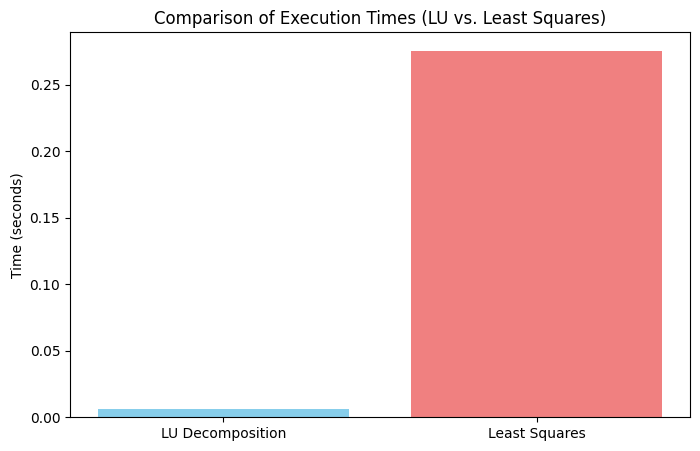

In [ ]:
import matplotlib.pyplot as plt

methods = ['LU Decomposition', 'Least Squares']
times = [lu_time, lstsq_time]

plt.figure(figsize=(8, 5))
plt.bar(methods, times, color=['skyblue', 'lightcoral'])
plt.title('Comparison of Execution Times (LU vs. Least Squares)')
plt.ylabel('Time (seconds)')
plt.show()

## Step 3: Residual Analysis — Measuring Reconstruction Quality
### Frobenius Residual
```
r = ||reconstructed - original||_F
```
The Frobenius norm squares every pixel difference, sums them all, and takes the square root. It gives a **single number representing total error** across the whole image.

**Lower residual = closer to original = better restoration.**

### PSNR (Peak Signal-to-Noise Ratio)
```
PSNR = 10 × log10(255² / MSE)
```

PSNR is standardised in decibels (dB) so it can be compared across different images and projects.

| PSNR | Quality |
|---|---|
| Above 40 dB | Excellent |
| 30–40 dB | Good |
| 20–30 dB | Acceptable |
| Below 20 dB | Poor |


**We calculate both metrics for every stage** — noisy, blurred, LU reconstructed, and Least Squares reconstructed — to show how each step in the pipeline affected image quality.

In [ ]:
def frobenius_residual(a, b):
    return np.linalg.norm(a.astype(float) - b.astype(float), 'fro')

print("Noisy vs Original:  ", frobenius_residual(noisy_image, smaller_image))
print("Blurred vs Original:", frobenius_residual(blurred_image, smaller_image))
print("LU vs Original:     ", frobenius_residual(lu_reconstructed, smaller_image))
print("LSTSQ vs Original:  ", frobenius_residual(lstsq_reconstructed, smaller_image))

def psnr(original, reconstructed):
    mse = np.mean((original.astype(float) - reconstructed.astype(float)) ** 2)
    return 10 * np.log10(255**2 / mse)

print("PSNR Noisy:  ", psnr(smaller_image, noisy_image))
print("PSNR Blurred:", psnr(smaller_image, blurred_image))
print("PSNR LU:     ", psnr(smaller_image, lu_reconstructed))
print("PSNR LSTSQ:  ", psnr(smaller_image, lstsq_reconstructed))

Noisy vs Original:   1985.9902822354022
Blurred vs Original: 1047.3901372010619
LU vs Original:      1272.093611000776
LSTSQ vs Original:   1272.0936110007976
PSNR Noisy:   22.17126122681982
PSNR Blurred: 27.728634008076693
PSNR LU:      26.04042218046277
PSNR LSTSQ:   26.04042218046262


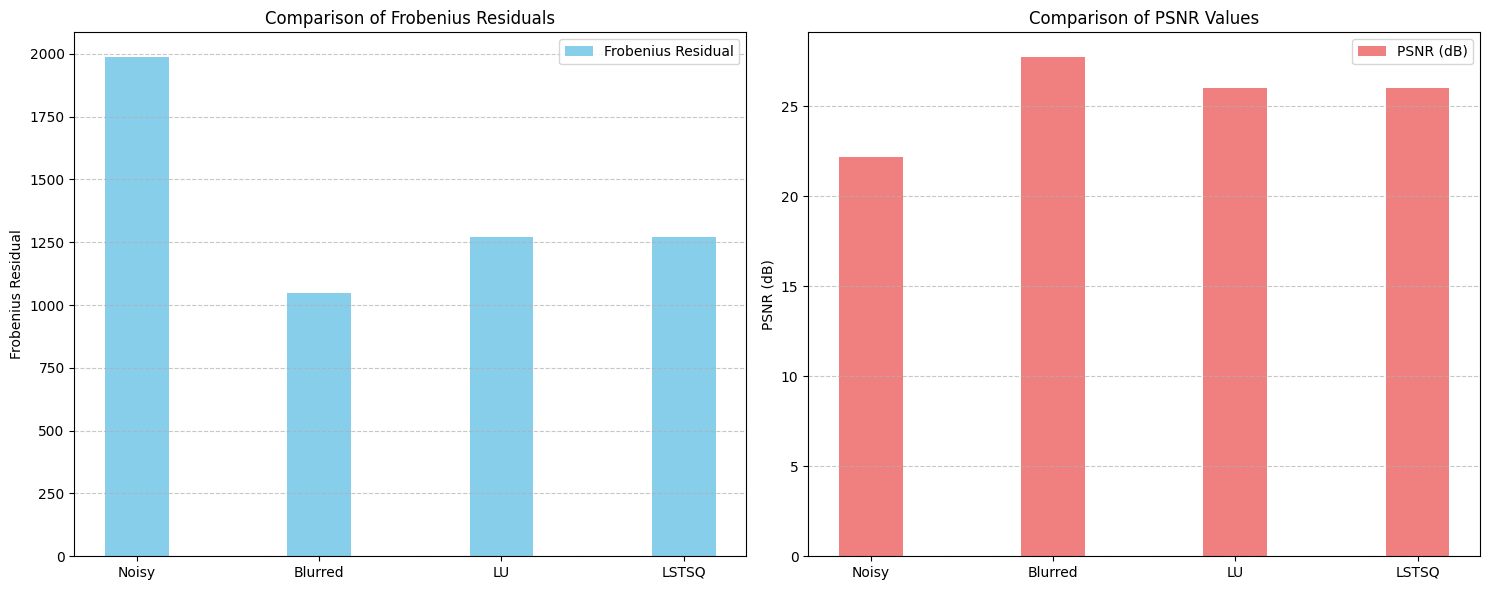

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from previous cell's output
methods = ['Noisy', 'Blurred', 'LU', 'LSTSQ']

frobenius_residuals = [
    frobenius_residual(noisy_image, smaller_image),
    frobenius_residual(blurred_image, smaller_image),
    frobenius_residual(lu_reconstructed, smaller_image),
    frobenius_residual(lstsq_reconstructed, smaller_image)
]

psnr_values = [
    psnr(smaller_image, noisy_image),
    psnr(smaller_image, blurred_image),
    psnr(smaller_image, lu_reconstructed),
    psnr(smaller_image, lstsq_reconstructed)
]

x = np.arange(len(methods))  # the label locations
width = 0.35  # the width of the bars

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot for Frobenius Residuals
ax1.bar(x, frobenius_residuals, width, label='Frobenius Residual', color='skyblue')
ax1.set_ylabel('Frobenius Residual')
ax1.set_title('Comparison of Frobenius Residuals')
ax1.set_xticks(x)
ax1.set_xticklabels(methods)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Plot for PSNR Values
ax2.bar(x, psnr_values, width, label='PSNR (dB)', color='lightcoral')
ax2.set_ylabel('PSNR (dB)')
ax2.set_title('Comparison of PSNR Values')
ax2.set_xticks(x)
ax2.set_xticklabels(methods)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()